# Pronóstico de Demanda

El pronóstico de demanda es una capacidad crítica para las operaciones de salud, incluidas las redes de clínicas veterinarias.

Predecir con precisión el número de visitas veterinarias diarias permite a las organizaciones asignar mejor al personal, gestionar la capacidad de las clínicas y optimizar los sistemas de programación de citas.

Dentro de la red de clínicas veterinarias Mexikans, comprender los patrones de demanda ayuda a responder preguntas operativas clave:

- ¿Cuándo deben esperar las clínicas una mayor demanda?
- ¿Qué tan estable es la demanda veterinaria a lo largo del tiempo?
- ¿Qué factores impulsan las fluctuaciones en la actividad de las clínicas?

En este notebook construyo modelos de machine learning para pronosticar el **volumen diario de visitas veterinarias** para cada clínica de la red.

El flujo de trabajo de pronóstico sigue las siguientes etapas principales:

1. Cargar el dataset de pronóstico  
2. Explorar patrones temporales de demanda  
3. Preparar las características para el modelado  
4. Realizar una división train-test basada en el tiempo  
5. Entrenar modelos de pronóstico  
6. Evaluar el desempeño predictivo  
7. Analizar los errores de pronóstico  
8. Interpretar los factores que impulsan el modelo  

La variable objetivo de los modelos de pronóstico es **daily_visits**, que representa el número de consultas veterinarias realizadas por una clínica en un día determinado.

In [1]:
"""
Configuración del Entorno
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

# Configuración de guardado de gráficos
NOTEBOOK_ID = "05_demand_forecasting"

FIGURES_DIR = Path("../figures")

def save_plot(name):
    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Entorno listo.")

Entorno listo.


## Cargar el Dataset de Pronóstico

El dataset utilizado para el pronóstico fue generado durante la etapa de ingeniería de características.

Contiene datos operativos diarios para cada clínica, incluyendo varias características de series temporales diseñadas para capturar patrones de demanda.

Estas características incluyen:

- variables de demanda rezagada (lag)
- estadísticas móviles de demanda
- indicadores de tendencia de demanda
- características temporales del calendario

In [2]:
"""
Cargar Dataset
"""

DATA_PATH = "../data/"

forecast_df = pd.read_csv(
    DATA_PATH + "demand_forecasting_features.csv"
)

forecast_df["visit_date"] = pd.to_datetime(
    forecast_df["visit_date"]
)

forecast_df.head()

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean,demand_trend_7d
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
"""
Visión General del Dataset
"""

print("Tamaño del dataset:", forecast_df.shape)

forecast_df.describe()

Tamaño del dataset: (90917, 26)


,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean,demand_trend_7d
count,90917,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90867.000000,90567.000000,90217.00000,89417.000000,90567.000000,89417.000000,90567.000000,90217.000000,89417.000000,90567.000000,89417.000000,90567.000000,89417.000000,89417.000000
mean,2022-07-02 14:57:20.227900160,8.287130,1230.553563,8.230375,8.228186,149.020923,3.003839,6.520596,26.598128,2.507716,0.286338,8.287255,8.285899,8.28631,8.286758,1230.563544,1230.799557,8.288129,8.290020,8.294520,2.775171,2.848765,1230.875568,1231.873027,0.006380
min,2020-01-01 00:00:00,1.000000,21.950000,1.000000,1.000000,21.950000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.00000,1.000000,21.950000,21.950000,1.428571,2.071429,2.800000,0.377964,1.093345,105.700000,274.053000,-4.700000
25%,2021-04-02 00:00:00,5.000000,532.570000,5.000000,5.000000,89.175385,1.000000,4.000000,14.000000,2.000000,0.000000,5.000000,5.000000,5.00000,5.000000,532.340000,532.330000,5.428571,5.428571,5.466667,1.976047,2.233496,768.264286,798.311667,-0.585714
50%,2022-07-03 00:00:00,7.000000,1025.740000,7.000000,7.000000,129.345000,3.000000,7.000000,27.000000,3.000000,0.000000,7.000000,7.000000,7.00000,7.000000,1025.680000,1025.730000,7.285714,7.214286,7.166667,2.609506,2.690127,1092.060000,1078.248333,0.000000
75%,2023-10-03 00:00:00,11.000000,1706.030000,11.000000,11.000000,186.827500,5.000000,10.000000,40.000000,4.000000,1.000000,11.000000,11.000000,11.00000,11.000000,1706.440000,1707.100000,10.285714,10.214286,10.166667,3.387653,3.322684,1583.782857,1583.299000,0.595238
max,2024-12-31 00:00:00,33.000000,7544.650000,33.000000,33.000000,1773.550000,6.000000,12.000000,53.000000,4.000000,1.000000,33.000000,33.000000,33.00000,33.000000,7544.650000,7544.650000,25.000000,22.857143,21.566667,8.783101,6.459867,4126.277143,3483.054667,4.742857
std,NaN,4.794987,910.221412,4.732322,4.730192,86.058673,1.999493,3.447830,15.062550,1.116926,0.452052,4.795109,4.794317,4.79395,4.794544,910.368308,910.517532,3.918491,3.847050,3.809243,1.100880,0.824958,613.683044,567.505777,0.939910


## Demanda de la Red a lo Largo del Tiempo

Antes de construir modelos de pronóstico, es importante examinar cómo evoluciona la demanda veterinaria a lo largo del tiempo.

La siguiente visualización muestra el número total de visitas veterinarias en todas las clínicas de la red para cada día del dataset.

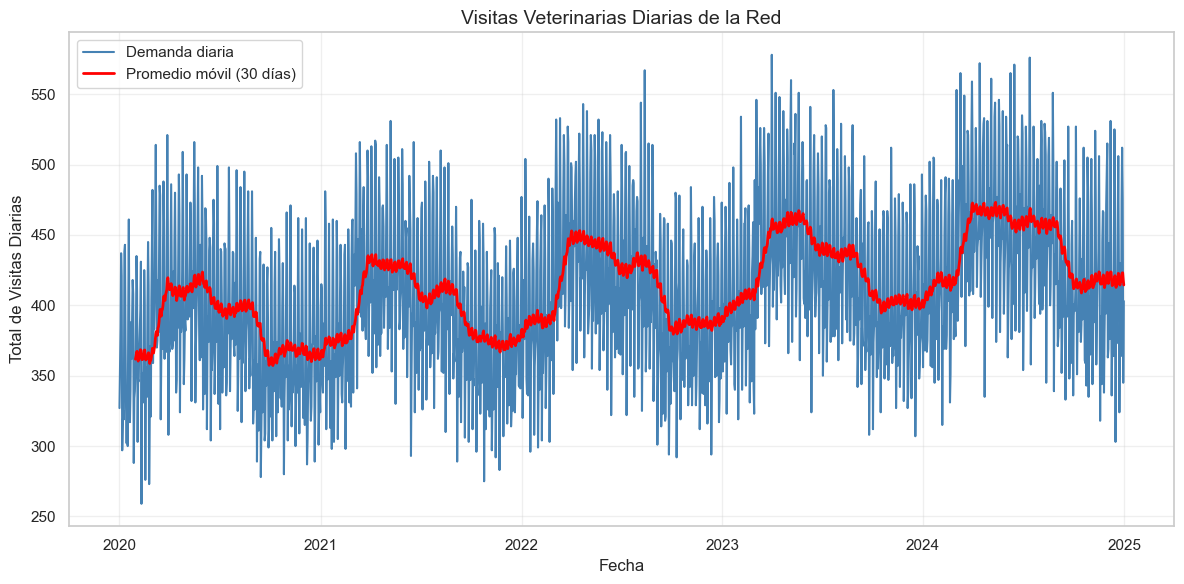

In [4]:
network_demand = (
    forecast_df
    .groupby("visit_date")["daily_visits"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=network_demand,
    x="visit_date",
    y="daily_visits",
    label="Demanda diaria",
    color="steelblue"
)

rolling_mean = network_demand["daily_visits"].rolling(30).mean()

plt.plot(
    network_demand["visit_date"],
    rolling_mean,
    color="red",
    linewidth=2,
    label="Promedio móvil (30 días)"
)

plt.title("Visitas Veterinarias Diarias de la Red")

plt.xlabel("Fecha")
plt.ylabel("Total de Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("network_demand_timeseries")

plt.tight_layout()

plt.show()

## Patrones Semanales de Demanda

La demanda veterinaria suele seguir patrones de comportamiento semanales.

Los dueños de mascotas pueden preferir programar citas en determinados días de la semana, lo que puede generar fluctuaciones sistemáticas en la actividad de las clínicas.

La siguiente visualización examina cómo varía el volumen de visitas según el día de la semana.

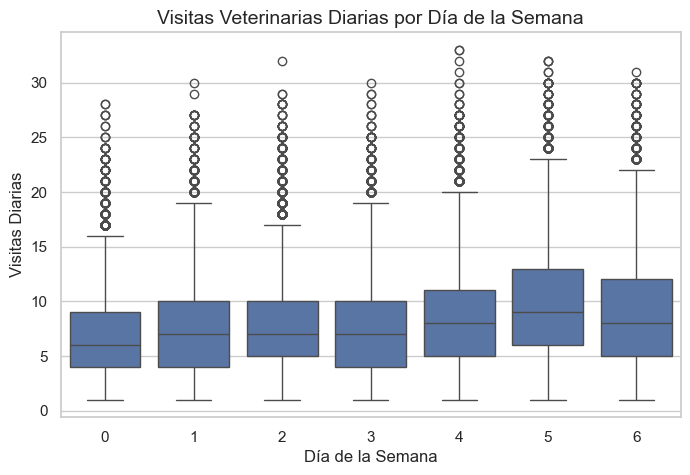

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="day_of_week",
    y="daily_visits",
    data=forecast_df
)

plt.title("Visitas Veterinarias Diarias por Día de la Semana")

plt.xlabel("Día de la Semana")

plt.ylabel("Visitas Diarias")

plt.show()

## Selección de Características

Los modelos de pronóstico se basan en características de series temporales generadas en la etapa anterior del proyecto.

Estas características capturan varios aspectos del comportamiento de la demanda:

- niveles recientes de demanda (variables de rezago)
- tendencias de demanda a corto plazo (promedios móviles)
- volatilidad de la demanda
- efectos del calendario

In [6]:
features = [

    "lag_1_visits",
    "lag_7_visits",
    "lag_14_visits",
    "lag_30_visits",

    "rolling_7d_visits_mean",
    "rolling_30d_visits_mean",

    "rolling_7d_visits_std",

    "demand_trend_7d",

    "day_of_week",
    "month",
    "is_weekend"
]

forecast_df[features].head()

,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,rolling_7d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,demand_trend_7d,day_of_week,month,is_weekend
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,0
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,0
2,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0
3,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
4,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,1,1


In [7]:
"""
Manejo de Valores Faltantes
"""

data_model = forecast_df.dropna()

X = data_model[features]

y = data_model["daily_visits"]

print("Tamaño del dataset después de eliminar valores faltantes:", X.shape)

Tamaño del dataset después de eliminar valores faltantes: (89417, 11)


## Análisis de Correlación de Características

Antes de entrenar los modelos de pronóstico, es útil examinar las relaciones entre las características de series temporales generadas.

El análisis de correlación ayuda a identificar dependencias entre variables y proporciona información sobre cómo se relacionan entre sí los diferentes indicadores de demanda.

Comprender estas relaciones puede ayudar a interpretar el comportamiento del modelo e identificar posibles redundancias entre características.

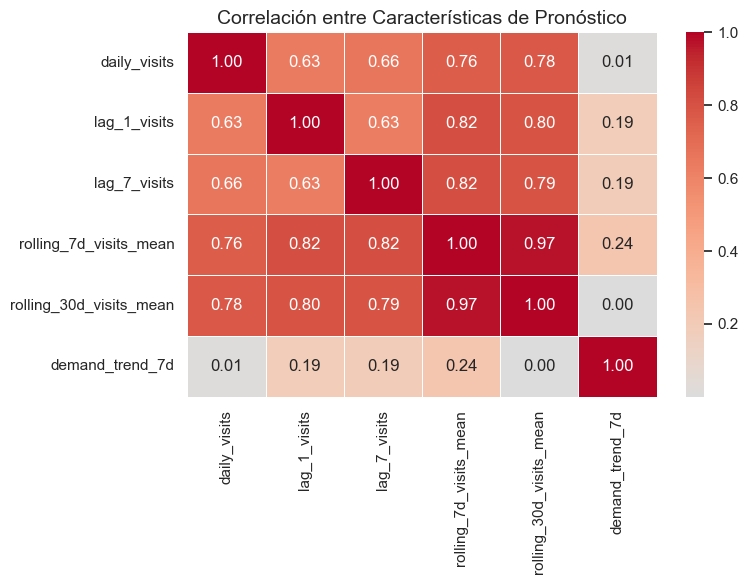

In [8]:
corr_features = data_model[
    [
        "daily_visits",
        "lag_1_visits",
        "lag_7_visits",
        "rolling_7d_visits_mean",
        "rolling_30d_visits_mean",
        "demand_trend_7d"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_features.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre Características de Pronóstico")

save_plot("forecast_feature_correlation")

plt.tight_layout()

plt.show()

## División Train-Test Basada en el Tiempo

Al construir modelos de pronóstico, es esencial preservar el orden cronológico de las observaciones.

En lugar de dividir el dataset de forma aleatoria, divido los datos basándome en el tiempo.

Las observaciones más antiguas se utilizan para entrenar los modelos, mientras que las observaciones más recientes se reservan para evaluar el desempeño del pronóstico.

In [9]:
data_model = data_model.sort_values("visit_date")

split_date = data_model["visit_date"].quantile(0.8)

train = data_model[data_model["visit_date"] <= split_date]

test = data_model[data_model["visit_date"] > split_date]

X_train = train[features]

y_train = train["daily_visits"]

X_test = test[features]

y_test = test["daily_visits"]

print("Tamaño del conjunto de entrenamiento:", X_train.shape)

print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (71566, 11)
Tamaño del conjunto de prueba: (17851, 11)


## Estrategia de Entrenamiento de Modelos

Para evaluar el problema de pronóstico desde múltiples perspectivas, entreno varios modelos con niveles crecientes de complejidad.

La estrategia de modelado incluye:

1. **Modelo Baseline Naive**  
   Un modelo simple de persistencia donde la demanda de mañana es igual a la demanda de hoy.

2. **Regresión Lineal**  
   Un modelo predictivo básico que captura relaciones lineales entre las características y la demanda.

3. **Random Forest**  
   Un modelo ensemble no lineal capaz de capturar interacciones complejas entre las características.

4. **Gradient Boosting**  
   Un modelo basado en boosting diseñado para mejorar la precisión predictiva mediante aprendizaje secuencial.

Comparar estos modelos permite determinar si enfoques más sofisticados mejoran significativamente el desempeño del pronóstico.

## Pronóstico Baseline Naive

Antes de entrenar modelos de machine learning, es útil establecer un punto de referencia simple para el pronóstico.

Un baseline común en el pronóstico de series temporales es el **pronóstico naive**, donde la predicción para la siguiente observación es simplemente el valor observado más reciente.

En este caso, el pronóstico asume que el número de visitas veterinarias de mañana será igual al número observado hoy.

Este baseline se implementa utilizando la característica **lag_1_visits**.

Aunque es simple, los pronósticos naive a menudo funcionan sorprendentemente bien y proporcionan un punto de referencia útil para evaluar modelos más complejos.

In [10]:
"""
Pronóstico Baseline Naive
"""

pred_naive = X_test["lag_1_visits"]

mae_naive = mean_absolute_error(y_test, pred_naive)

rmse_naive = np.sqrt(mean_squared_error(y_test, pred_naive))

r2_naive = r2_score(y_test, pred_naive)

print("Desempeño del Pronóstico Naive")

print("MAE:", mae_naive)

print("RMSE:", rmse_naive)

print("R²:", r2_naive)

Desempeño del Pronóstico Naive
MAE: 3.246316732956137
RMSE: 4.215565587399661
R²: 0.29249616906363585


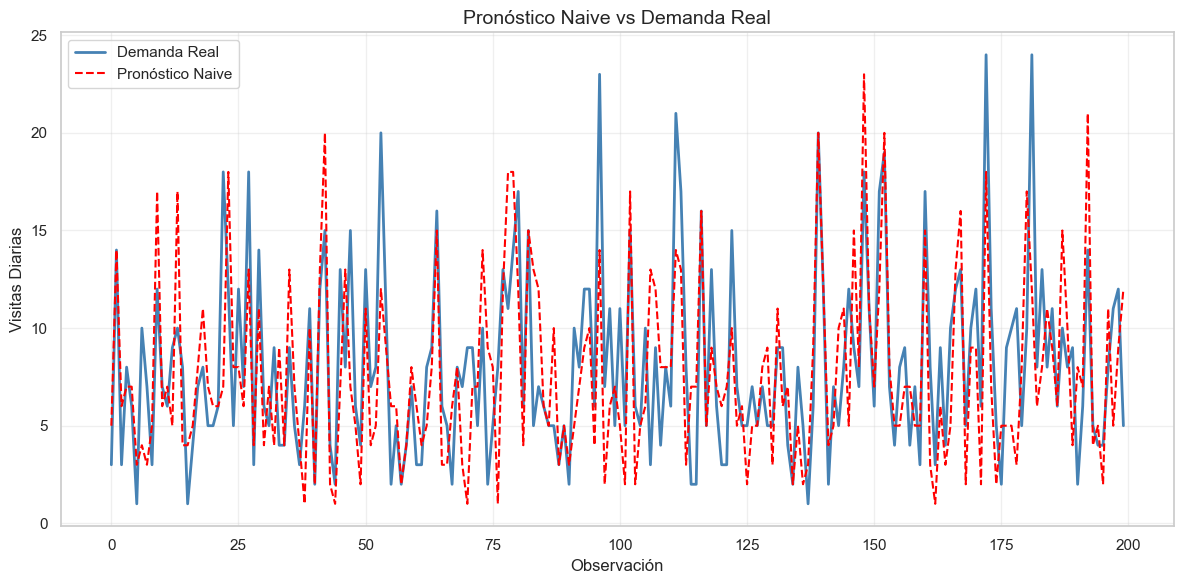

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Demanda Real",
    color="steelblue",
    linewidth=2
)

plt.plot(
    pred_naive.values[:200],
    label="Pronóstico Naive",
    color="red",
    linestyle="--"
)

plt.title("Pronóstico Naive vs Demanda Real")

plt.xlabel("Observación")
plt.ylabel("Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("naive_forecast_vs_actual")

plt.tight_layout()

plt.show()

## Modelo de Regresión Lineal

Después de establecer el baseline naive, entreno un modelo de regresión lineal utilizando las características de series temporales generadas.

La regresión lineal sirve como un modelo simple pero interpretable que puede capturar relaciones entre la demanda y las variables explicativas.

Aunque los patrones de demanda pueden incluir efectos no lineales, este modelo proporciona un punto de referencia útil antes de aplicar algoritmos más complejos.

In [12]:
"""
Modelo de Regresión Lineal
"""

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

r2_lr = r2_score(y_test, pred_lr)

print("Desempeño de Regresión Lineal")

print("MAE:", mae_lr)

print("RMSE:", rmse_lr)

print("R²:", r2_lr)

Desempeño de Regresión Lineal
MAE: 2.316851333106778
RMSE: 2.969007728797969
R²: 0.649054441178223


## Modelo Random Forest

Random Forest es un método de aprendizaje ensemble que construye múltiples árboles de decisión y agrega sus predicciones.

Este enfoque es adecuado para el pronóstico de demanda porque puede capturar relaciones no lineales e interacciones entre variables.

Los modelos Random Forest también son robustos al ruido y pueden manejar patrones complejos en datos operativos.

In [13]:
"""
Modelo Random Forest
"""

rf = RandomForestRegressor(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

r2_rf = r2_score(y_test, pred_rf)

print("Desempeño de Random Forest")

print("MAE:", mae_rf)

print("RMSE:", rmse_rf)

print("R²:", r2_rf)

Desempeño de Random Forest
MAE: 2.339077549343641
RMSE: 2.987282311893603
R²: 0.6447209251211965


In [14]:
"""
Modelo Gradient Boosting
"""

gb = GradientBoostingRegressor(

    n_estimators=300,

    learning_rate=0.05,

    random_state=42

)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb)

rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))

r2_gb = r2_score(y_test, pred_gb)

print("Desempeño de Gradient Boosting")

print("MAE:", mae_gb)

print("RMSE:", rmse_gb)

print("R²:", r2_gb)

Desempeño de Gradient Boosting
MAE: 2.2797291496255045
RMSE: 2.9112495727228165
R²: 0.6625759994583424


## Comparación del Desempeño de los Modelos

Para evaluar la efectividad de los modelos de pronóstico, comparo su desempeño utilizando tres métricas de evaluación:

**Error Absoluto Medio (MAE)**  
Mide la magnitud promedio de los errores de predicción.

**Raíz del Error Cuadrático Medio (RMSE)**  
Penaliza con mayor fuerza los errores de predicción más grandes.

**Coeficiente de Determinación (R²)**  
Representa la proporción de la varianza en la demanda explicada por el modelo.

Comparar múltiples modelos permite determinar si los enfoques de machine learning mejoran los baselines simples de pronóstico.

In [15]:
results = pd.DataFrame({

    "Model":[
        "Naive Forecast",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        mae_naive,
        mae_lr,
        mae_rf,
        mae_gb
    ],

    "RMSE":[
        rmse_naive,
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],

    "R2":[
        r2_naive,
        r2_lr,
        r2_rf,
        r2_gb
    ]

})

results

,Model,MAE,RMSE,R2
0,Naive Forecast,3.246317,4.215566,0.292496
1,Linear Regression,2.316851,2.969008,0.649054
2,Random Forest,2.339078,2.987282,0.644721
3,Gradient Boosting,2.279729,2.911250,0.662576


/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_2181/2052552719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


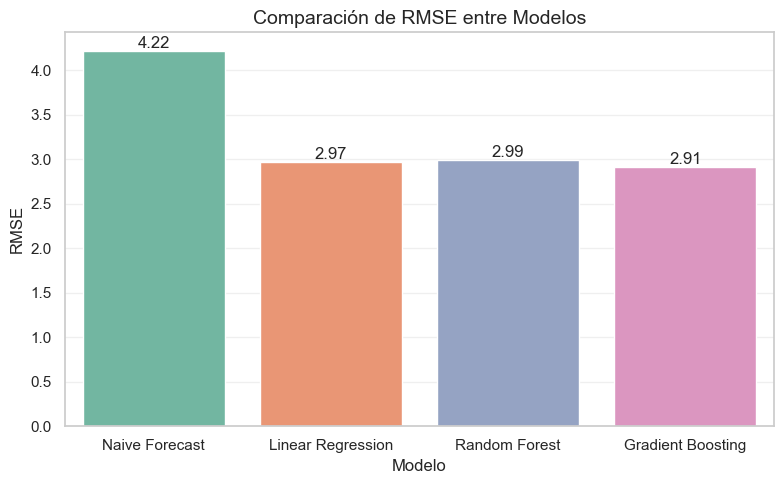

In [16]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="RMSE",
    palette="Set2"
)

plt.title("Comparación de RMSE entre Modelos")

plt.xlabel("Modelo")
plt.ylabel("RMSE")

# adicionar valores nas barras
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f"{p.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

save_plot("model_rmse_comparison")

plt.tight_layout()

plt.show()

### Selección del Modelo

Tras evaluar distintos modelos de machine learning, se seleccionó **Gradient Boosting Regressor** como modelo final para la predicción de la demanda.

La selección se basó en una comparación objetiva utilizando métricas estándar de regresión:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**
- **R² (Coeficiente de determinación)**

Entre los modelos evaluados — incluyendo regresión lineal y Random Forest — el modelo de Gradient Boosting presentó el mejor desempeño global:

- menor error promedio (MAE)
- menor penalización de errores grandes (RMSE)
- mayor capacidad explicativa (R²)

Estos resultados indican que Gradient Boosting captura de forma más efectiva las relaciones no lineales presentes en los datos, así como los patrones temporales complejos de la demanda.

### Interpretación

La superioridad del modelo sugiere que la demanda de visitas veterinarias no sigue un comportamiento puramente lineal, sino que depende de múltiples factores interrelacionados, como:

- patrones recientes de demanda
- tendencias de corto plazo
- variabilidad en la actividad de las clínicas

Los modelos basados en árboles, como Gradient Boosting, son especialmente adecuados para este tipo de problemas, ya que pueden adaptarse a estructuras complejas en los datos sin necesidad de supuestos estrictos.

### Conclusión

En base a estos resultados, el modelo de Gradient Boosting fue seleccionado como el modelo final para la generación de predicciones, garantizando un mejor equilibrio entre precisión y robustez en la estimación de la demanda.

## Visualización del Pronóstico

Para evaluar visualmente el modelo de pronóstico, comparo los valores de demanda predichos con la demanda real observada en el conjunto de prueba.

Esta visualización ayuda a evaluar si el modelo captura los patrones subyacentes en la actividad de las clínicas veterinarias.

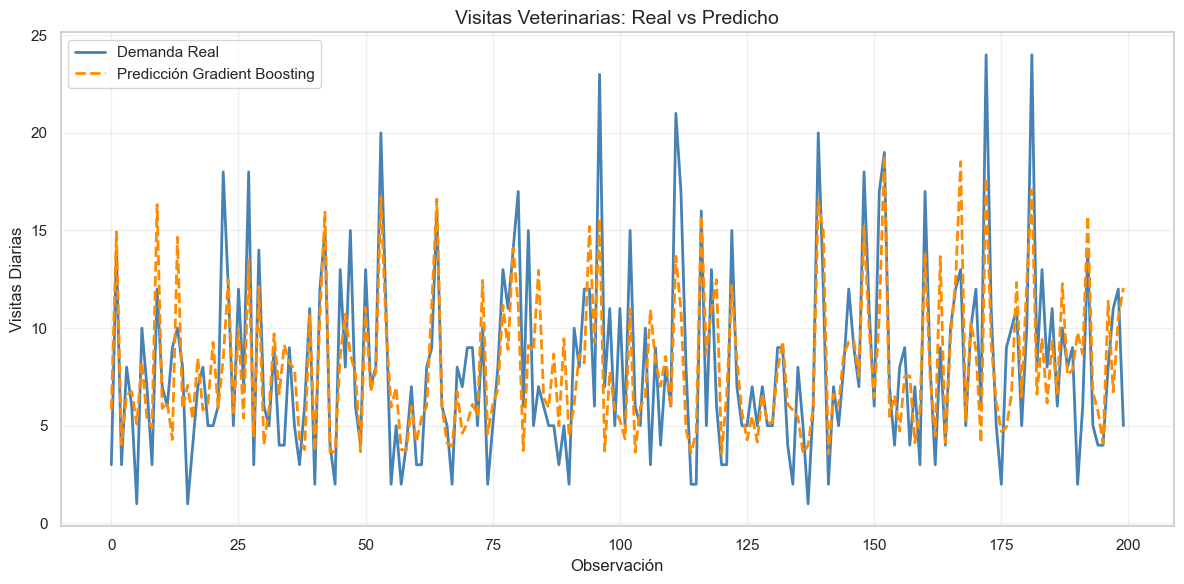

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Demanda Real",
    color="steelblue",
    linewidth=2
)

plt.plot(
    pred_gb[:200],
    label="Predicción Gradient Boosting",
    color="darkorange",
    linestyle="--",
    linewidth=2
)

plt.title("Visitas Veterinarias: Real vs Predicho")

plt.xlabel("Observación")
plt.ylabel("Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("gradient_boosting_forecast_vs_actual")

plt.tight_layout()

plt.show()

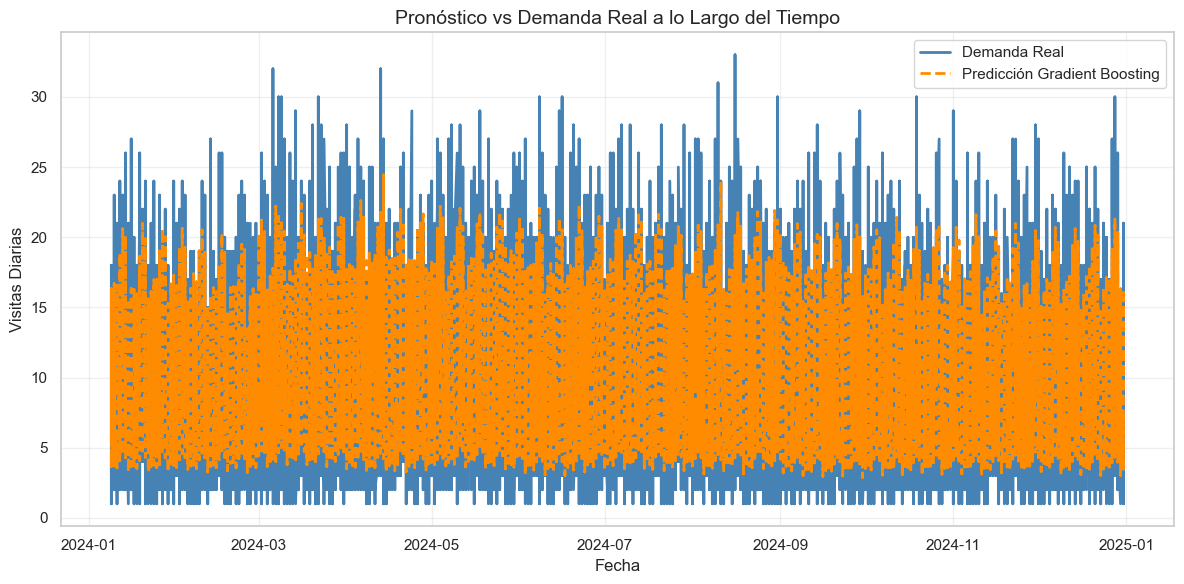

In [18]:
forecast_plot_df = test.copy()

forecast_plot_df["prediction"] = pred_gb

plt.figure(figsize=(12,6))

plt.plot(
    forecast_plot_df["visit_date"],
    forecast_plot_df["daily_visits"],
    label="Demanda Real",
    color="steelblue",
    linewidth=2
)

plt.plot(
    forecast_plot_df["visit_date"],
    forecast_plot_df["prediction"],
    label="Predicción Gradient Boosting",
    color="darkorange",
    linestyle="--",
    linewidth=2
)

plt.title("Pronóstico vs Demanda Real a lo Largo del Tiempo")

plt.xlabel("Fecha")
plt.ylabel("Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("forecast_vs_actual_timeseries")

plt.tight_layout()

plt.show()

## Visualización de la Precisión de las Predicciones

Otra forma útil de evaluar el desempeño del pronóstico es comparar los valores predichos con los valores reales observados.

Si el modelo funciona bien, los valores predichos deberían alinearse estrechamente con los niveles de demanda observados.

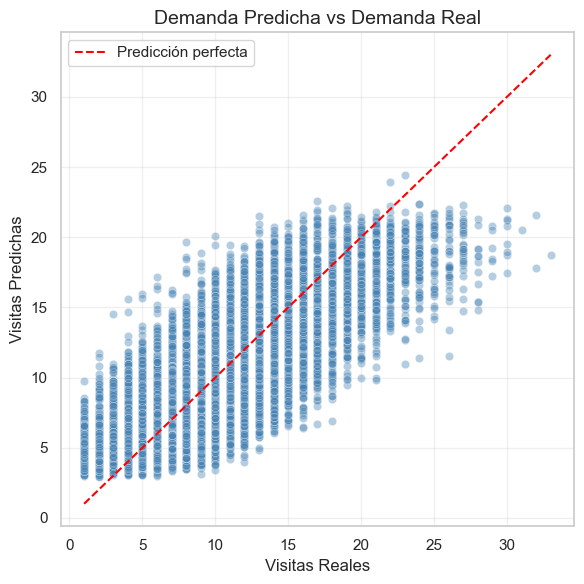

In [19]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test,
    y=pred_gb,
    alpha=0.4,
    color="steelblue"
)

# linha ideal (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red",
    label="Predicción perfecta"
)

plt.title("Demanda Predicha vs Demanda Real")

plt.xlabel("Visitas Reales")
plt.ylabel("Visitas Predichas")

plt.legend()

plt.grid(alpha=0.3)

save_plot("predicted_vs_actual_scatter")

plt.tight_layout()

plt.show()

## Análisis de Residuos

El análisis de residuos es un paso importante en la evaluación de modelos de pronóstico.

Los residuos representan la diferencia entre los valores observados y las predicciones del modelo.

Analizar los residuos ayuda a detectar posibles problemas como:

- sesgo sistemático en las predicciones
- errores de predicción inusualmente grandes
- patrones que el modelo no logró capturar

Idealmente, los residuos deberían distribuirse aleatoriamente alrededor de cero sin una estructura clara.

In [20]:
residuals = y_test - pred_gb

residuals.head()

52384   -2.834955
23340   -0.932034
45100   -1.024905
3288     1.426383
16066   -0.744472
Name: daily_visits, dtype: float64

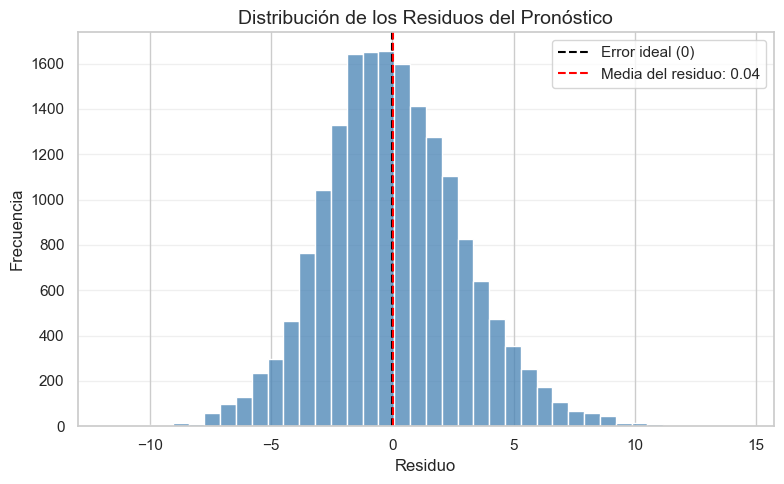

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=40,
    color="steelblue"
)

mean_res = residuals.mean()

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="Error ideal (0)"
)

plt.axvline(
    mean_res,
    color="red",
    linestyle="--",
    label=f"Media del residuo: {mean_res:.2f}"
)

plt.title("Distribución de los Residuos del Pronóstico")

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("forecast_residual_distribution")

plt.tight_layout()

plt.show()

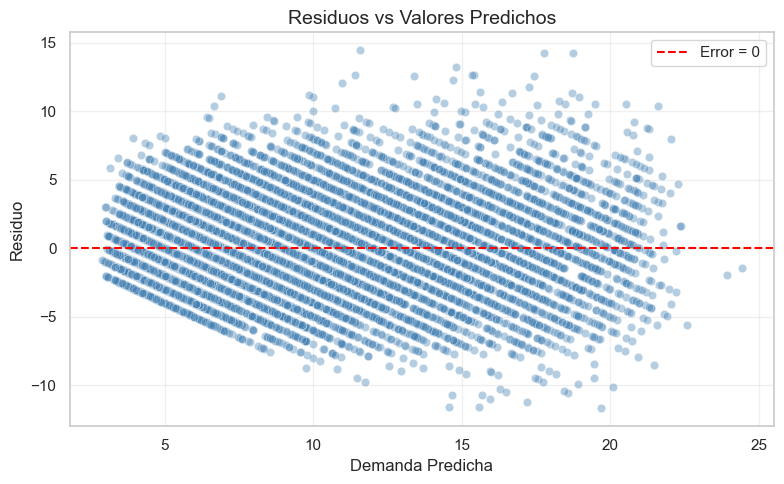

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=pred_gb,
    y=residuals,
    alpha=0.4,
    color="steelblue"
)

plt.axhline(
    0,
    linestyle="--",
    color="red",
    label="Error = 0"
)

plt.title("Residuos vs Valores Predichos")

plt.xlabel("Demanda Predicha")
plt.ylabel("Residuo")

plt.legend()

plt.grid(alpha=0.3)

save_plot("residuals_vs_predictions")

plt.tight_layout()

plt.show()

## Error de Pronóstico a lo Largo del Tiempo

Evaluar los errores de pronóstico a lo largo del tiempo ayuda a identificar si el modelo mantiene un desempeño consistente en diferentes períodos.

Los períodos con mayores errores de pronóstico pueden indicar comportamientos de demanda inusuales o interrupciones operativas.

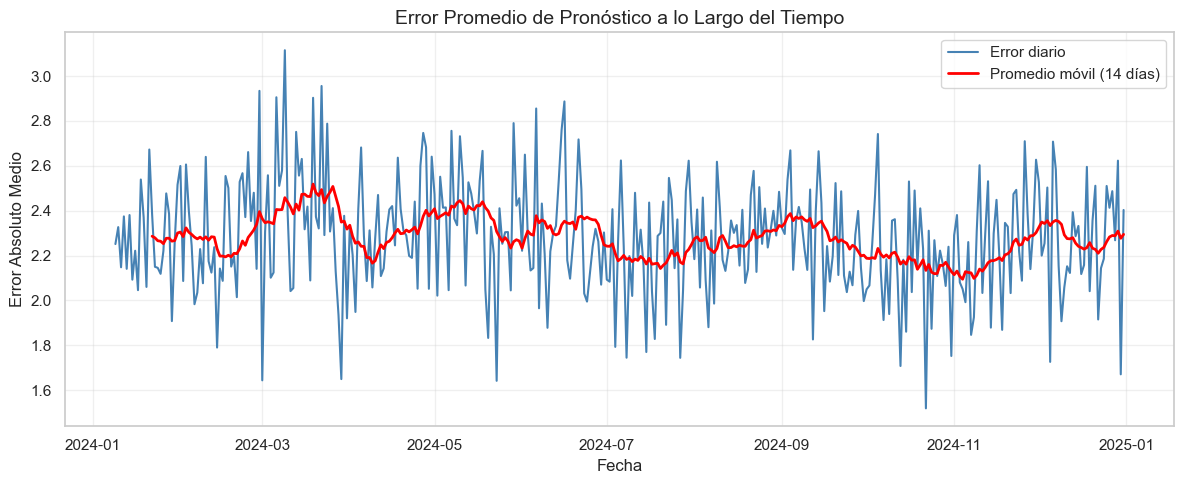

In [23]:
error_by_date = (
    forecast_plot_df
    .assign(
        error = abs(
            forecast_plot_df["daily_visits"]
            - forecast_plot_df["prediction"]
        )
    )
    .groupby("visit_date")["error"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=error_by_date,
    x="visit_date",
    y="error",
    label="Error diario",
    color="steelblue"
)

rolling_error = error_by_date["error"].rolling(14).mean()

plt.plot(
    error_by_date["visit_date"],
    rolling_error,
    color="red",
    linewidth=2,
    label="Promedio móvil (14 días)"
)

plt.title("Error Promedio de Pronóstico a lo Largo del Tiempo")

plt.xlabel("Fecha")
plt.ylabel("Error Absoluto Medio")

plt.legend()

plt.grid(alpha=0.3)

save_plot("forecast_error_over_time")

plt.tight_layout()

plt.show()

## Importancia de las Características

Los modelos Gradient Boosting proporcionan una medida de la importancia de las características basada en cuánto contribuye cada variable a reducir el error de predicción.

Analizar la importancia de las características ayuda a identificar los principales impulsores de la demanda en las clínicas veterinarias.

Comprender estos impulsores puede proporcionar información útil para la planificación operativa.

In [24]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

rolling_30d_visits_mean    0.643378
rolling_7d_visits_std      0.060119
demand_trend_7d            0.051617
day_of_week                0.049788
lag_30_visits              0.034336
lag_14_visits              0.034322
lag_1_visits               0.032949
lag_7_visits               0.032812
month                      0.032288
rolling_7d_visits_mean     0.026828
is_weekend                 0.001564
dtype: float64

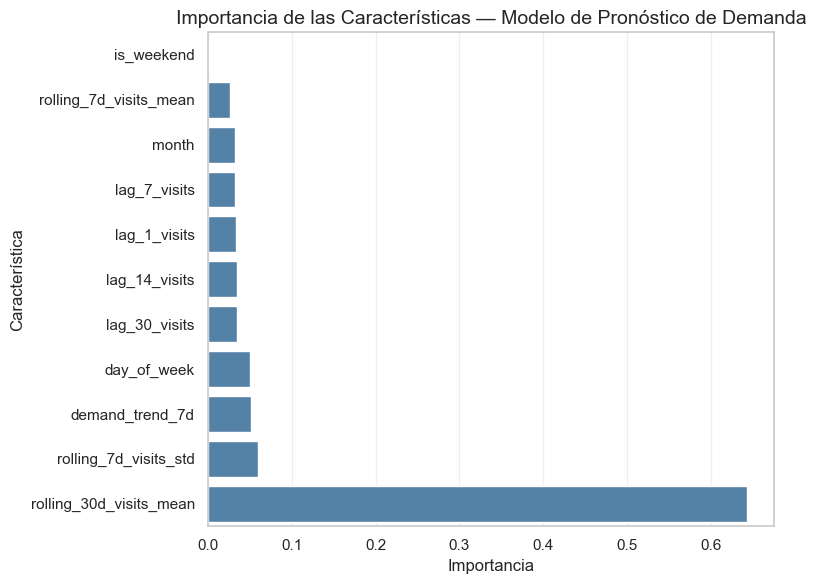

In [25]:
importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))

sns.barplot(
    x=importance_sorted.values,
    y=importance_sorted.index,
    color="steelblue"
)

plt.title("Importancia de las Características — Modelo de Pronóstico de Demanda")

plt.xlabel("Importancia")
plt.ylabel("Característica")

plt.grid(axis="x", alpha=0.3)

save_plot("forecast_feature_importance")

plt.tight_layout()

plt.show()

In [26]:
test["prediction"] = pred_gb

test["absolute_error"] = abs(
    test["daily_visits"] - test["prediction"]
)

error_by_clinic = (
    test
    .groupby("clinic_id")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

error_by_clinic.head()

/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_2181/1213586956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["prediction"] = pred_gb
/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_2181/1213586956.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["absolute_error"] = abs(


clinic_id
C012    3.399391
C005    3.316786
C013    3.313901
C018    3.307557
C046    3.217594
Name: absolute_error, dtype: float64

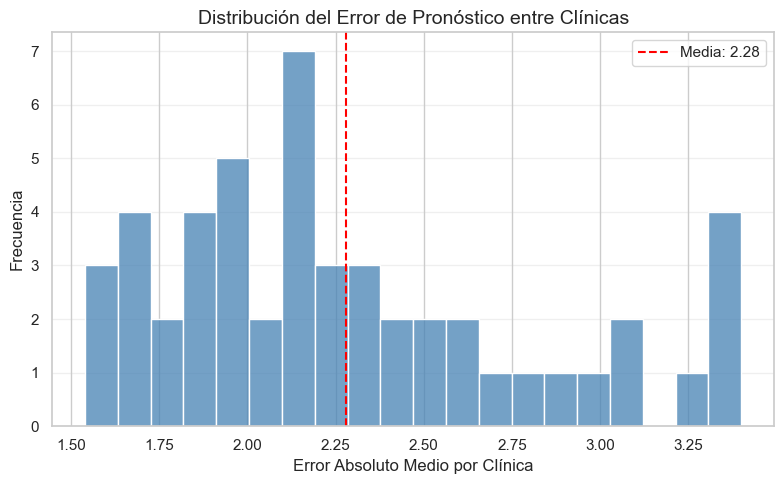

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    error_by_clinic,
    bins=20,
    color="steelblue"
)

mean_error = error_by_clinic.mean()

plt.axvline(
    mean_error,
    linestyle="--",
    color="red",
    label=f"Media: {mean_error:.2f}"
)

plt.title("Distribución del Error de Pronóstico entre Clínicas")

plt.xlabel("Error Absoluto Medio por Clínica")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("forecast_error_by_clinic_distribution")

plt.tight_layout()

plt.show()

## Guardar Resultados del Pronóstico

El paso final del flujo de trabajo de pronóstico es almacenar las predicciones del modelo para análisis posteriores.

Guardar los resultados del pronóstico permite su futura integración con sistemas de reportes, dashboards o herramientas de toma de decisiones operativas.

En este paso, exporto los valores de demanda predicha junto con la demanda observada para cada clínica y fecha en el conjunto de datos de prueba.

In [28]:
"""
Guardar Resultados del Pronóstico
"""

forecast_results = test.copy()

forecast_results["prediction"] = pred_gb

forecast_results["residual"] = (
    forecast_results["daily_visits"]
    - forecast_results["prediction"]
)

forecast_results["absolute_error"] = abs(
    forecast_results["residual"]
)

forecast_results.head()

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean,demand_trend_7d,prediction,absolute_error,residual
52384,C029,2024-01-09,3,172.78,3,3,57.593333,1,1,2,1,0,5.0,7.0,6.0,4.0,1243.18,583.87,6.142857,5.642857,6.233333,1.069045,2.608783,732.741429,890.792000,-0.090476,5.834955,2.834955,-2.834955
23340,C013,2024-01-09,14,1560.27,14,14,111.447857,1,1,2,1,0,14.0,17.0,14.0,10.0,2025.18,667.12,18.000000,16.857143,15.800000,3.785939,3.836306,2169.011429,2084.427667,2.200000,14.932034,0.932034,-0.932034
45100,C025,2024-01-09,3,601.83,3,3,200.610000,1,1,2,1,0,6.0,2.0,1.0,2.0,802.67,980.00,4.714286,4.500000,4.200000,2.429972,1.788854,1024.012857,676.389333,0.514286,4.024905,1.024905,-1.024905
3288,C002,2024-01-09,8,1369.30,8,8,171.162500,1,1,2,1,0,7.0,5.0,9.0,11.0,599.44,1240.95,6.285714,6.357143,7.133333,2.288689,2.270247,911.405714,947.980000,-0.847619,6.573617,1.426383,1.426383
16066,C009,2024-01-09,6,1018.68,6,6,169.780000,1,1,2,1,0,7.0,8.0,13.0,5.0,753.09,1435.56,7.428571,7.571429,7.233333,3.154739,2.459091,1192.132857,1069.529333,0.195238,6.744472,0.744472,-0.744472


In [29]:
"""
Exportar Resultados del Pronóstico
"""

OUTPUT_PATH = "../data/"

forecast_results.to_csv(
    OUTPUT_PATH + "forecast_predictions.csv",
    index=False
)

print("Predicciones de pronóstico guardadas correctamente.")

Predicciones de pronóstico guardadas correctamente.
